#Rafael Giordano Fuentes Bonnett

# Avaliação Prática: Classificação de Espécies de *Tyrannus* com Redes Neurais

Nesta avaliação, você irá projetar e treinar um discriminador feito com uma rede MLP para classificar três espécies de aves do gênero *Tyrannus* com base em medidas morfológicas corporais, utilizando PyTorch.

---

## Contexto

O gênero *Tyrannus* (família Tyrannidae) reúne os chamados "suiriris" e "tesourinhas", aves passeriformes amplamente distribuídas nas Américas. MacPherson et al. mediram características morfológicas de espécimes de museu para investigar a relação entre morfologia e estratégia migratória.

---

## Exercício 1

Projete e treine uma rede neural MLP em PyTorch que receba o vetor de 2 características morfológicas e produza a classificação entre as três espécies.

### Dados

O banco de dados original conta com diversas características morfológicas por indivíduo. Neste primeiro exercício, utilizaremos apenas 2 delas:

| Coluna | Descrição | Unidade |
|---|---|---|
| `wing_chord` | Comprimento da asa | mm |
| `tail_length` | Comprimento da cauda | mm |

O dataset fornecido já contém apenas essas 2 características. As três classes-alvo são:
- **Classe 0:** *Tyrannus tyrannus* (Suiriri-valente)
- **Classe 1:** *Tyrannus melancholicus* (Suiriri-comum)
- **Classe 2:** *Tyrannus savana* (Tesourinha)

Utilize para treinamento os dados do arquivo [`data_train.csv`](./data_train.csv) e para teste os dados do arquivo [`data_test.csv`](./data_test.csv).

Para fins de comparação, treine também um modelo de regressão logística multiclasse, interpretado como uma rede neural com **zero** camadas ocultas (entrada → camada linear → softmax). Esse modelo serve como referência de desempenho mínimo que sua MLP deve superar.

Considere as seguintes diretrizes:
- Use os dados de teste para monitorar o overfitting e observe as curvas de aprendizado;
- Salve os pesos do modelo ao final de cada época e carregue o melhor modelo segundo a função custo de teste (checkpoint);
- Projete a arquitetura livremente. Número de camadas, neurônios e hiperparâmetros são suas escolhas, e devem ser justificados;
- Use `CrossEntropyLoss`, que incorpora o Softmax internamente; portanto, **não** adicione ativação Softmax na camada de saída.

## Exercício 2: Sexo das aves

O banco de dados também fornece o sexo das aves, bem como características morfológicas adicionais. Para investigar a presença de dimorfismo sexual em *Tyrannus melancholicus*, utilizaremos um conjunto de dados adicional contendo todas as 7 características morfológicas originais, além do sexo de cada indivíduo.

Para este exercício, utilize para treinamento os dados do arquivo [`data_extra_train.csv`](./data_extra_train.csv) e para teste os dados do arquivo [`data_extra_test.csv`](./data_extra_test.csv).

Treine um discriminador MLP cujo objetivo é classificar o **sexo** do indivíduo (variável binária: 0 = fêmea, 1 = macho).

Com base nos resultados obtidos, é possível afirmar que *Tyrannus melancholicus* apresenta dimorfismo sexual nessas características morfológicas? Justifique.

## Instruções para entrega

- O exercício deve ser feito **individualmente**;

- A entrega deve incluir:
  - Um vídeo de no **máximo 1m30s**, mostrando a resolução do exercício;
  - Os **códigos-fontes** dos programas, preferencialmente organizados em um Jupyter Notebook, descrevendo o experimento e mostrando como foram obtidos os resultados solicitados, incluindo:

1. Arquitetura escolhida e hiperparâmetros, justificados em células Markdown. Utilize as técnicas para evitar a convergência para mínimos locais e para evitar o *overfitting*, ainda que seja possível obter um bom desempenho com uma rede mais simples;
2. Código completo de treinamento e teste;
3. Curvas de aprendizado (função custo de treino vs. teste);
4. Matriz de confusão, acurácia e F1-score macro no conjunto de teste;
5. Comparação com o modelo de regressão logística, com discussão dos resultados.

- Sobre o vídeo:
  - **Deve incluir áudio** descrevendo o experimento;
  - Gravem a tela do computador usando celular ou usando algum programa de captura de tela (por exemplo Zoom, Google Meet, ou OBS Studio);
  - No início, **deve aparecer o rosto e algum documento do aluno que gravou o vídeo** (como a carteira USP, RG, CNH, etc);
  - Tentem fazer um bom aproveitamento do tempo para apresentar os resultados solicitados, **respeitando o limite de 1m30s e não acelerem a velocidade do vídeo**;

- Sobre os códigos-fonte:
  - **Incluir o nome do aluno** no início do programa;

- Sobre o envio no Moodle:
  - Podem ser enviados o arquivo de vídeo (.mkv, .mp4, .avi, etc.) ou um link para o vídeo (Youtube, Google Drive, etc);
    - No segundo caso, certifiquem-se que todos os professores/pesquisadores (magno.silva@usp.br, hae.kim@usp.br,  sergiocaceres01@usp.br, renatocan@lps.usp.br) tenham acesso ao seu vídeo.
  - Não se esqueçam de escrever o nome do aluno em três lugares diferentes: **no campo "comentários sobre o envio" no Moodle**, **no início do vídeo** e no **início dos códigos-fonte**.

#Exercicio1

inicializacion

In [469]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn

from sklearn.metrics import confusion_matrix,f1_score,accuracy_score

np.random.seed(111)
torch.manual_seed(111)

carga de datos

In [470]:
train_df=pd.read_csv("data_train.csv")
test_df=pd.read_csv("data_test.csv")

X_train_np=train_df[["wing_chord","tail_length"]].values
y_train_np=train_df["label"].values

X_test_np=test_df[["wing_chord","tail_length"]].values
y_test_np=test_df["label"].values

# conversión a tensor
X_train=torch.tensor(X_train_np,dtype=torch.float32)
y_train=torch.tensor(y_train_np,dtype=torch.long)

X_test=torch.tensor(X_test_np,dtype=torch.float32)
y_test=torch.tensor(y_test_np,dtype=torch.long)

O treinamento foi realizado utilizando mini-batches para melhorar a estabilidade do gradiente e acelerar o processo de treinamento.

DataLoader

In [471]:
Nb=32

train_set=[(X_train[i],y_train[i]) for i in range(X_train.shape[0])]
train_loader=torch.utils.data.DataLoader(train_set,batch_size=Nb,shuffle=True)

## Arquitetura da MLP

Foi utilizada uma rede MLP com duas camadas ocultas.

A primeira camada possui 8 neurônios e a segunda 8 neurônios, permitindo que a rede aprenda relações não lineares entre as características morfológicas e o sexo das aves.

A função ReLU foi escolhida por apresentar boa convergência e baixo custo computacional.

Modelo

In [472]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.model=nn.Sequential(
            nn.Linear(2,8),
            nn.ReLU(),
            nn.Linear(8,8),
            nn.ReLU(),
            nn.Linear(8,3)
        )

    def forward(self,x):
        return self.model(x)

device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model=Model().to(device=device)

## Função custo e otimização

Foi utilizada a função CrossEntropyLoss, apropriada para problemas de classificação.

O otimizador Adam foi escolhido devido à sua rápida convergência em redes neurais pequenas e médias.

Loss y optimizador

In [473]:
loss_function=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.01)

entrenamiento

In [474]:
Ne=200

losses=[]
test_losses=[]

best_loss=1e9

for epoch in range(Ne):

    for X,d in train_loader:

        X=X.to(device=device)
        d=d.to(device=device)

        model.train()
        model.zero_grad()

        y=model(X)

        loss=loss_function(y,d)
        loss.backward()
        optimizer.step()

    # evaluación en test
    model.eval()
    with torch.no_grad():
        y_test_pred=model(X_test.to(device=device))
        test_loss=loss_function(y_test_pred,y_test.to(device=device))

    losses.append(loss.item())
    test_losses.append(test_loss.item())

    if test_loss.item()<best_loss:
        best_loss=test_loss.item()
        torch.save(model.state_dict(),"best_model.pth")

    if epoch%20==0:
        print(f"epoch:{epoch} loss:{loss.item()} test_loss:{test_loss.item()}")

epoch:0 loss:0.6927571296691895 test_loss:0.7746973633766174
epoch:20 loss:0.327376127243042 test_loss:0.38862866163253784
epoch:40 loss:0.2563548684120178 test_loss:0.23547358810901642
epoch:60 loss:0.4791976809501648 test_loss:0.09780572354793549
epoch:80 loss:0.05544348806142807 test_loss:0.06768197566270828
epoch:100 loss:0.3160673677921295 test_loss:0.05809788033366203
epoch:120 loss:0.03565449267625809 test_loss:0.05096500366926193
epoch:140 loss:0.02716844156384468 test_loss:0.040457114577293396
epoch:160 loss:0.01165091060101986 test_loss:0.042804501950740814
epoch:180 loss:0.009045325219631195 test_loss:0.040408920496702194


plot

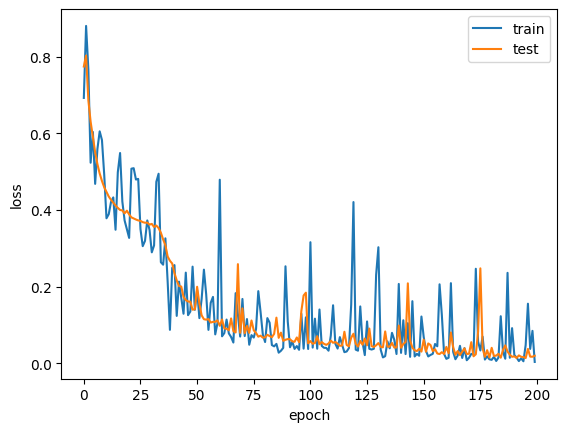

In [475]:
plt.plot(losses)
plt.plot(test_losses)
plt.legend(["train","test"])
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

Modelo de Regresión Logistica

In [476]:
class LogisticModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear=nn.Linear(2,3)

    def forward(self,x):
        return self.linear(x)

log_model=LogisticModel().to(device=device)

optimizer_log=torch.optim.Adam(log_model.parameters(),lr=0.01)

for epoch in range(Ne):
    for X,d in train_loader:

        X=X.to(device=device)
        d=d.to(device=device)

        log_model.train()
        log_model.zero_grad()

        y=log_model(X)
        loss=loss_function(y,d)

        loss.backward()
        optimizer_log.step()

Métricas

MLP
accuracy: 1.0
f1: 1.0

Regresion Logistica
accuracy: 0.9896907216494846
f1: 0.991788629667198


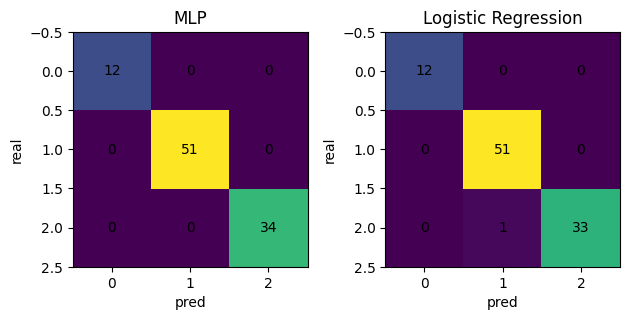

In [477]:
from sklearn.metrics import confusion_matrix,f1_score,accuracy_score
import matplotlib.pyplot as plt

#MLP
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

with torch.no_grad():
    y_pred_mlp=model(X_test.to(device=device))
    y_pred_mlp=torch.argmax(y_pred_mlp,dim=1).cpu().numpy()

acc_mlp=accuracy_score(y_test_np,y_pred_mlp)
f1_mlp=f1_score(y_test_np,y_pred_mlp,average="macro")
cm_mlp=confusion_matrix(y_test_np,y_pred_mlp)

#Regresion logistica
log_model.eval()

with torch.no_grad():
    y_pred_log=log_model(X_test.to(device=device))
    y_pred_log=torch.argmax(y_pred_log,dim=1).cpu().numpy()

acc_log=accuracy_score(y_test_np,y_pred_log)
f1_log=f1_score(y_test_np,y_pred_log,average="macro")
cm_log=confusion_matrix(y_test_np,y_pred_log)

#comparacion numerica
print("MLP")
print("accuracy:",acc_mlp)
print("f1:",f1_mlp)

print("\nRegresion Logistica")
print("accuracy:",acc_log)
print("f1:",f1_log)

# grafica

fig,axs=plt.subplots(1,2)

# MLP
axs[0].imshow(cm_mlp)
axs[0].set_title("MLP")
axs[0].set_xlabel("pred")
axs[0].set_ylabel("real")

for i in range(cm_mlp.shape[0]):
    for j in range(cm_mlp.shape[1]):
        axs[0].text(j,i,cm_mlp[i,j],ha="center",va="center")

# Logistica
axs[1].imshow(cm_log)
axs[1].set_title("Logistic Regression")
axs[1].set_xlabel("pred")
axs[1].set_ylabel("real")

for i in range(cm_log.shape[0]):
    for j in range(cm_log.shape[1]):
        axs[1].text(j,i,cm_log[i,j],ha="center",va="center")

plt.tight_layout()
plt.show()

#Exercicio 2

Carga de Datos

In [478]:
train_df=pd.read_csv("data_extra_train.csv")
test_df=pd.read_csv("data_extra_test.csv")

# primeiras 7 colunas = características morfológicas
X_train_np=train_df.iloc[:,:7].values
y_train_np=train_df.iloc[:,7].values

X_test_np=test_df.iloc[:,:7].values
y_test_np=test_df.iloc[:,7].values

# tensor
X_train=torch.tensor(X_train_np,dtype=torch.float32)
y_train=torch.tensor(y_train_np,dtype=torch.long)

X_test=torch.tensor(X_test_np,dtype=torch.float32)
y_test=torch.tensor(y_test_np,dtype=torch.long)

As variáveis morfológicas possuem escalas diferentes.  
A normalização foi utilizada para melhorar a convergência da rede neural e evitar que atributos com valores maiores dominem o treinamento.

Normalizacion

In [479]:
mean=X_train.mean(dim=0)
std=X_train.std(dim=0)

X_train=(X_train-mean)/std
X_test=(X_test-mean)/std

Data Loader

In [480]:
Nb=32

train_set=[(X_train[i],y_train[i]) for i in range(X_train.shape[0])]

train_loader=torch.utils.data.DataLoader(
    train_set,
    batch_size=Nb,
    shuffle=True
)

Modelo MLP

In [481]:
class Model(nn.Module):

    def __init__(self):
        super().__init__()

        self.model=nn.Sequential(
            nn.Linear(7,6),
            nn.ReLU(),
            nn.Linear(6,8),
            nn.ReLU(),
            nn.Linear(8,2)
        )

    def forward(self,x):
        return self.model(x)
device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model=Model().to(device=device)

Também foi utilizada regularização L2 através do parâmetro weight_decay para melhorar a generalização do modelo.

loss

In [482]:
loss_function=nn.CrossEntropyLoss()

optimizer=torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

entrenamiento

In [483]:
Ne=100

losses=[]
test_losses=[]

best_loss=1e9

for epoch in range(Ne):

    model.train()

    train_loss=0

    for X,d in train_loader:

        X=X.to(device=device)
        d=d.to(device=device)
        model.zero_grad()
        y=model(X)
        loss=loss_function(y,d)
        loss.backward()
        optimizer.step()
        train_loss+=loss.item()

    train_loss=train_loss/len(train_loader)

    # test
    model.eval()

    with torch.no_grad():

        y_test_pred=model(X_test.to(device=device))

        test_loss=loss_function(
            y_test_pred,
            y_test.to(device=device)
        )

    losses.append(train_loss)
    test_losses.append(test_loss.item())

    # checkpoint
    if test_loss.item()<best_loss:

        best_loss=test_loss.item()

        torch.save(
            model.state_dict(),
            "best_model_extra.pth"
        )

    if epoch%20==0:

        print(
            f"epoch:{epoch} "
            f"train_loss:{train_loss:.4f} "
            f"test_loss:{test_loss.item():.4f}"
        )

epoch:0 train_loss:0.6800 test_loss:0.6970
epoch:20 train_loss:0.5951 test_loss:0.6240
epoch:40 train_loss:0.4960 test_loss:0.5811
epoch:60 train_loss:0.4337 test_loss:0.5963
epoch:80 train_loss:0.4461 test_loss:0.6092


test

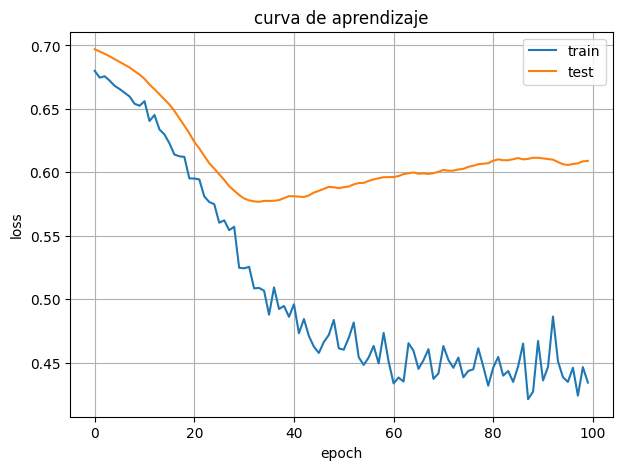

In [484]:
plt.figure(figsize=(7,5))

plt.plot(losses)
plt.plot(test_losses)

plt.xlabel("epoch")
plt.ylabel("loss")

plt.legend(["train","test"])

plt.title("curva de aprendizaje")

plt.grid()

plt.show()


model.load_state_dict(
    torch.load("best_model_extra.pth")
)

model.eval()

with torch.no_grad():

    y_pred=model(X_test.to(device=device))

    y_pred=torch.argmax(y_pred,dim=1)

    y_pred=y_pred.cpu().numpy()


grafica

MLP
accuracy: 0.7045454545454546
f1-score: 0.7346938775510204


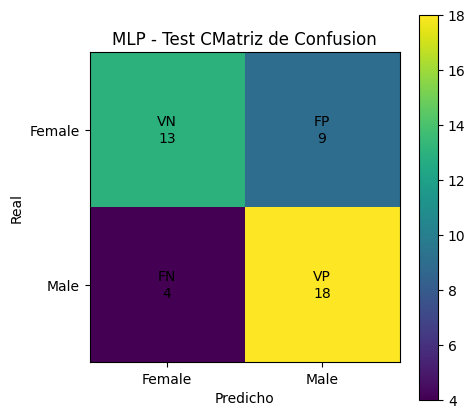

In [485]:
acc_mlp=accuracy_score(
    y_test_np,
    y_pred
)

f1_mlp=f1_score(
    y_test_np,
    y_pred,
    average="binary"
)

cm_mlp=confusion_matrix(
    y_test_np,
    y_pred
)

print("MLP")
print("accuracy:",acc_mlp)
print("f1-score:",f1_mlp)

# matriz de confusao

plt.figure(figsize=(5,5))

plt.imshow(cm_mlp)

plt.title("MLP - Test CMatriz de Confusion")

plt.xlabel("Predicho")
plt.ylabel("Real")

plt.xticks(
    [0,1],
    ["Female","Male"]
)

plt.yticks(
    [0,1],
    ["Female","Male"]
)

labels=[
    ["VN","FP"],
    ["FN","VP"]
]

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            f"{labels[i][j]}\n{cm_mlp[i,j]}",
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

funcio logaritmica

In [486]:
class LogisticModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.linear=nn.Linear(7,2)

    def forward(self,x):
        return self.linear(x)
log_model=LogisticModel().to(device=device)

optimizer_log=torch.optim.Adam(
    log_model.parameters(),
    lr=0.001
)

log_losses=[]
log_test_losses=[]

best_log_loss=1e9

for epoch in range(Ne):

    log_model.train()

    train_loss=0

    for X,d in train_loader:

        X=X.to(device=device)
        d=d.to(device=device)

        log_model.zero_grad()

        y=log_model(X)

        loss=loss_function(y,d)

        loss.backward()

        optimizer_log.step()

        train_loss+=loss.item()

    train_loss=train_loss/len(train_loader)

    # teste
    log_model.eval()

    with torch.no_grad():

        y_test_pred=log_model(X_test.to(device=device))

        test_loss=loss_function(
            y_test_pred,
            y_test.to(device=device)
        )

    log_losses.append(train_loss)
    log_test_losses.append(test_loss.item())

    # checkpoint
    if test_loss.item()<best_log_loss:

        best_log_loss=test_loss.item()

        torch.save(
            log_model.state_dict(),
            "best_logistic_model.pth"
        )

test de func log

In [487]:
log_model.load_state_dict(
    torch.load("best_logistic_model.pth")
)

log_model.eval()

with torch.no_grad():

    y_pred_log=log_model(
        X_test.to(device=device)
    )

    y_pred_log=torch.argmax(
        y_pred_log,
        dim=1
    )

    y_pred_log=y_pred_log.cpu().numpy()

Regresion logistica
accuracy: 0.6818181818181818
f1-score: 0.6818181818181818


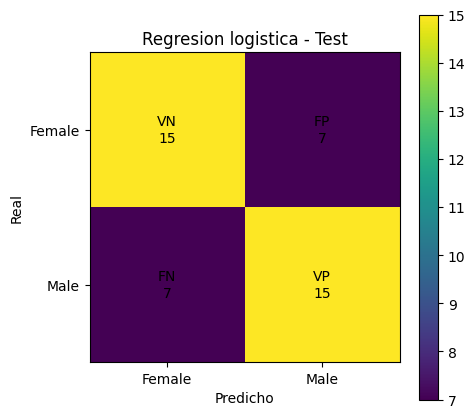

In [488]:
acc_log=accuracy_score(
    y_test_np,
    y_pred_log
)

f1_log=f1_score(
    y_test_np,
    y_pred_log,
    average="binary"
)

cm_log=confusion_matrix(
    y_test_np,
    y_pred_log
)
print("Regresion logistica")
print("accuracy:",acc_log)
print("f1-score:",f1_log)

# matriz de confusao

plt.figure(figsize=(5,5))

plt.imshow(cm_log)

plt.title("Regresion logistica - Test")

plt.xlabel("Predicho")
plt.ylabel("Real")

plt.xticks(
    [0,1],
    ["Female","Male"]
)

plt.yticks(
    [0,1],
    ["Female","Male"]
)

labels=[
    ["VN","FP"],
    ["FN","VP"]
]

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            f"{labels[i][j]}\n{cm_log[i,j]}",
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

Arquitetura (MLP): Foi escolhida uma rede com 2 camadas ocultas de 8 neurônios cada. Essa configuração foi adotada para permitir que a rede aprenda fronteiras de decisão não lineares entre as espécies, mantendo a simplicidade para evitar o overfitting dado o tamanho reduzido do dataset (apenas 2 características no Exercício 1).

Função de Ativação (ReLU): Utilizou-se a ReLU para as camadas ocultas por sua eficiência computacional e por mitigar o problema do "vanishing gradient", acelerando a convergência.

Otimizador (Adam) e Learning Rate (0.01): O Adam foi escolhido por possuir taxas de aprendizado adaptativas. O valor de 0.01 é um padrão sólido que permite uma convergência rápida sem oscilar excessivamente ao redor do mínimo local.

Batch Size (32): Um tamanho de lote pequeno ajuda na generalização do modelo e fornece uma estimativa de gradiente mais ruidosa, o que auxilia o modelo a escapar de mínimos locais.